In [1]:
import v0

In [6]:
rebalance_at = "2025-07-22"
r = v0.load(rebalance_at=rebalance_at)
raw = r["candidates"]
print(len(raw))

35639


In [7]:
filtered = v0.filter_candidates(raw)
print(filtered.iloc[0]["query_elapsed_seconds"], "seconds")

evaluated = v0.evaluate_candidates(filtered, rebalance_at=rebalance_at)
print(evaluated.iloc[0]["evaluation_elapsed_seconds"], "seconds")

scored = v0.score_candidates(evaluated)
best = scored[scored["eligible_for_ranking"]].head(50)
print(len(scored), "candidates")

12.465 seconds
4.989 seconds
1312 candidates


In [4]:
all_evaluated = v0.generate_all_evaluated(days=1, forward_days=1)
all_scored = v0.score_candidates(all_evaluated)
print(all_scored.iloc[0]["evaluation_elapsed_seconds"], "seconds")

372.016 seconds


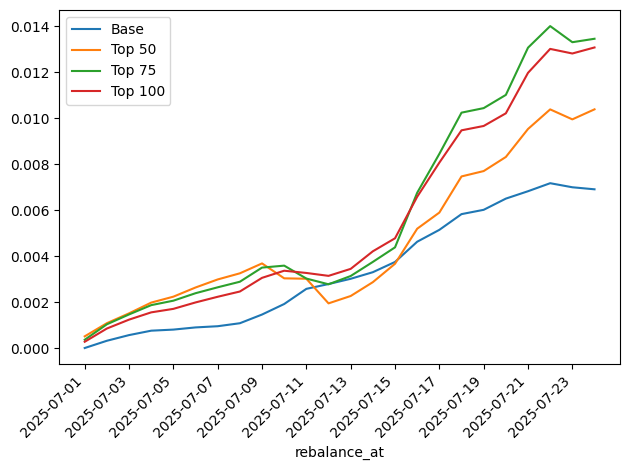

In [5]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots()

base = all_scored.groupby("rebalance_at")[
    "forward_return_on_history_notional"
].mean().cumsum()

top_50 = all_scored.groupby("rebalance_at").head(50).groupby("rebalance_at")[
    "forward_return_on_history_notional"
].mean().cumsum()

top_75 = all_scored.groupby("rebalance_at").head(75).groupby("rebalance_at")[
    "forward_return_on_history_notional"
].mean().cumsum()

top_100 = all_scored.groupby("rebalance_at").head(100).groupby("rebalance_at")[
    "forward_return_on_history_notional"
].mean().cumsum()

base.plot(ax=ax, label="Base")
top_50.plot(ax=ax, label="Top 50")
top_75.plot(ax=ax, label="Top 75")
top_100.plot(ax=ax, label="Top 100")

ax.legend()

labels = base.index.astype(str)
step = max(1, len(labels) // 10)

ax.set_xticks(np.arange(0, len(labels), step))
ax.set_xticklabels(labels[::step], rotation=45, ha="right")

plt.tight_layout()
plt.show()